In [5]:
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [7]:
df = pd.read_csv("manchester_postpartum_triage_v1.csv")
df['is_urgent'] = df['triage_level'].apply(lambda x: 0.0 if x == 0 else 1.0)

#(60% Train, 15% Val, 25% Test)
X_train, X_temp, y_train_orig, y_temp = train_test_split(
    df['patient_message'].astype(str).tolist(), 
    df['triage_level'].astype(int).tolist(), 
    test_size=0.40, 
    random_state=42, 
    stratify=df['triage_level'].astype(int).tolist()
)
X_val, X_test, y_val_orig, y_test_orig = train_test_split(
    X_temp, y_temp, test_size=0.625, random_state=42, stratify=y_temp
)

y_train_binary = [0.0 if x == 0 else 1.0 for x in y_train_orig]
y_val_binary = [0.0 if x == 0 else 1.0 for x in y_val_orig]
y_test_binary = [0.0 if x == 0 else 1.0 for x in y_test_orig]

MODEL_NAME = "dmis-lab/biobert-v1.1" 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TriageRegressionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32) 
        return item
    def __len__(self):
        return len(self.labels)

print("Preparing Stage 1: Binary Filter...")
train_dataset_binary = TriageRegressionDataset(X_train, y_train_binary, tokenizer)
val_dataset_binary = TriageRegressionDataset(X_val, y_val_binary, tokenizer)
test_dataset_binary = TriageRegressionDataset(X_test, y_test_binary, tokenizer)

model_stage1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits.squeeze()))
    preds = (probs >= 0.5).astype(int)
    return {"accuracy": accuracy_score(labels, preds)}

args_stage1 = TrainingArguments(
    output_dir="./results_stage1", num_train_epochs=3, per_device_train_batch_size=16,
    per_device_eval_batch_size=16, eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="accuracy", logging_steps=50
)

trainer_stage1 = Trainer(
    model=model_stage1, args=args_stage1, train_dataset=train_dataset_binary,
    eval_dataset=val_dataset_binary, compute_metrics=compute_metrics_binary,
)

print("Training Stage 1 (Binary BioBERT)...")
trainer_stage1.train()

Preparing Stage 1: Binary Filter...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Stage 1 (Binary BioBERT)...


C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.015600,0.000810,0.871111
2,0.004600,0.002434,0.966667
3,0.002600,0.000314,0.980000


C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=339, training_loss=0.023475904468238176, metrics={'train_runtime': 3541.6299, 'train_samples_per_second': 1.523, 'train_steps_per_second': 0.096, 'total_flos': 354802072499712.0, 'train_loss': 0.023475904468238176, 'epoch': 3.0})

In [9]:
print("\n Preparing Stage 2: Severity Regressor (Only Urgent Cases 1-3)...")

def filter_urgent_only(X_set, y_orig_set):
    X_filtered, y_filtered = [], []
    for text, label in zip(X_set, y_orig_set):
        if label > 0: 
            X_filtered.append(text)
            y_filtered.append(float(label))
    return X_filtered, y_filtered

X_train_s2, y_train_s2 = filter_urgent_only(X_train, y_train_orig)
X_val_s2, y_val_s2 = filter_urgent_only(X_val, y_val_orig)

train_dataset_stage2 = TriageRegressionDataset(X_train_s2, y_train_s2, tokenizer)
val_dataset_stage2 = TriageRegressionDataset(X_val_s2, y_val_s2, tokenizer)

model_stage2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=1)

def compute_metrics_regression(eval_pred):
    logits, labels = eval_pred
    preds = logits.squeeze()
    return {"mse": mean_squared_error(labels, preds), "mae": mean_absolute_error(labels, preds)}

args_stage2 = TrainingArguments(
    output_dir="./results_stage2", num_train_epochs=3, per_device_train_batch_size=16,
    per_device_eval_batch_size=16, eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="mse", greater_is_better=False, logging_steps=50
)

trainer_stage2 = Trainer(
    model=model_stage2, args=args_stage2, train_dataset=train_dataset_stage2,
    eval_dataset=val_dataset_stage2, compute_metrics=compute_metrics_regression,
)

print("Training Stage 2 (Severity BioBERT Regressor with MSE Loss)...")
trainer_stage2.train()


 Preparing Stage 2: Severity Regressor (Only Urgent Cases 1-3)...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at dmis-lab/biobert-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Stage 2 (Severity BioBERT Regressor with MSE Loss)...


C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Mse,Mae
1,0.596800,0.015916,0.015916,0.085473
2,0.042600,0.016698,0.016698,0.091610
3,0.017700,0.009638,0.009638,0.061278


C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=258, training_loss=0.14658107602781104, metrics={'train_runtime': 2464.6234, 'train_samples_per_second': 1.669, 'train_steps_per_second': 0.105, 'total_flos': 270541513569024.0, 'train_loss': 0.14658107602781104, 'epoch': 3.0})


🏁 GENERATING EVALUATION METRICS FOR FULL PIPELINE


C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



🔹 STAGE 1 (Binary Filter - Routine vs Urgent):
   • Accuracy: 0.9787
   • Macro F1-Score: 0.9697

📋 Detailed Stage 1 Report:
              precision    recall  f1-score   support

 Routine (0)       1.00      0.91      0.95       179
  Urgent (1)       0.97      1.00      0.99       571

    accuracy                           0.98       750
   macro avg       0.99      0.96      0.97       750
weighted avg       0.98      0.98      0.98       750



C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



🔹 STAGE 2 (Severity Regressor - Levels 1-3 Only):
   • Mean Squared Error (MSE): 0.0092
   • Accuracy (Rounded): 0.9947
   • Macro F1-Score (Rounded): 0.9947

📋 Detailed Stage 2 Report:
              precision    recall  f1-score   support

     Level 1       1.00      0.99      1.00       189
     Level 2       0.98      1.00      0.99       185
     Level 3       1.00      0.99      0.99       197

    accuracy                           0.99       571
   macro avg       0.99      0.99      0.99       571
weighted avg       0.99      0.99      0.99       571



C:\Users\1600n\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



👑 FINAL COMBINED CASCADE PIPELINE (Full Model 0-3):
   • Global Accuracy: 0.9747
   • Global Macro F1-Score: 0.9740

📋 Final Full Pipeline Classification Report:
              precision    recall  f1-score   support

     Level 0       1.00      0.91      0.95       179
     Level 1       0.96      0.99      0.98       189
     Level 2       0.94      1.00      0.97       185
     Level 3       1.00      0.99      0.99       197

    accuracy                           0.97       750
   macro avg       0.98      0.97      0.97       750
weighted avg       0.98      0.97      0.97       750



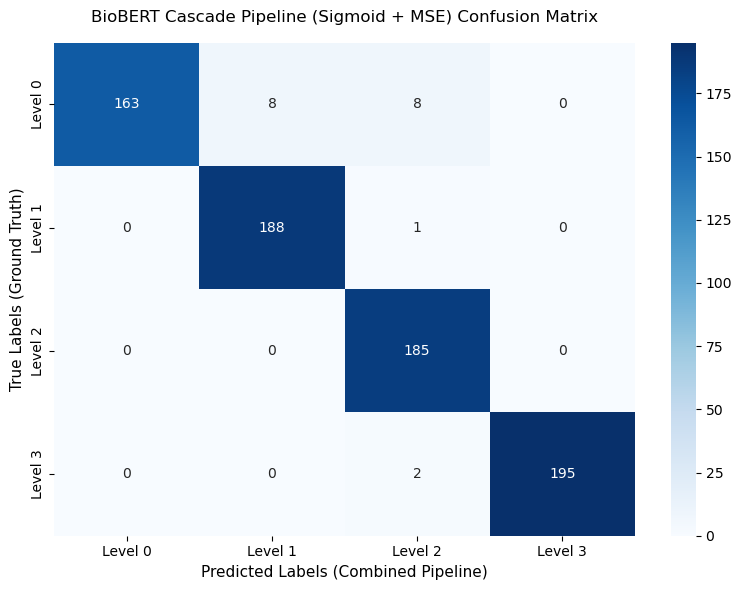

In [19]:
print("\n" + "="*50)
print("🏁 GENERATING EVALUATION METRICS FOR FULL PIPELINE")
print("="*50)

# prediction level 1 - binary
s1_predictions = trainer_stage1.predict(test_dataset_binary)
s1_logits = s1_predictions.predictions.squeeze()
s1_probs = 1 / (1 + np.exp(-s1_logits))
s1_preds = (s1_probs >= 0.5).astype(int)

print(f"\n🔹 STAGE 1 (Binary Filter - Routine vs Urgent):")
print(f"   • Accuracy: {accuracy_score(y_test_binary, s1_preds):.4f}")
print(f"   • Macro F1-Score: {f1_score(y_test_binary, s1_preds, average='macro'):.4f}")
print("\n📋 Detailed Stage 1 Report:")
print(classification_report(y_test_binary, s1_preds, target_names=["Routine (0)", "Urgent (1)"]))

# prediction level 2 - regretion
X_test_s2, y_test_s2_orig = filter_urgent_only(X_test, y_test_orig)
test_dataset_s2_only = TriageRegressionDataset(X_test_s2, y_test_s2_orig, tokenizer)

s2_only_predictions = trainer_stage2.predict(test_dataset_s2_only)
s2_only_preds_continuous = s2_only_predictions.predictions.squeeze()
s2_only_preds_rounded = np.clip(np.round(s2_only_preds_continuous), 1.0, 3.0).astype(int)
y_test_s2_orig_int = np.array(y_test_s2_orig).astype(int)

print(f"\n🔹 STAGE 2 (Severity Regressor - Levels 1-3 Only):")
print(f"   • Mean Squared Error (MSE): {mean_squared_error(y_test_s2_orig_int, s2_only_preds_continuous):.4f}")
print(f"   • Accuracy (Rounded): {accuracy_score(y_test_s2_orig_int, s2_only_preds_rounded):.4f}")
print(f"   • Macro F1-Score (Rounded): {f1_score(y_test_s2_orig_int, s2_only_preds_rounded, average='macro'):.4f}")
print("\n📋 Detailed Stage 2 Report:")
print(classification_report(y_test_s2_orig_int, s2_only_preds_rounded, target_names=["Level 1", "Level 2", "Level 3"]))

# pipeline
s2_full_predictions = trainer_stage2.predict(test_dataset_binary)
s2_full_preds_continuous = s2_full_predictions.predictions.squeeze()

final_pipeline_preds = []
for idx in range(len(X_test)):
    if s1_preds[idx] == 0:
        final_pipeline_preds.append(0)
    else:
        pred_scaled = np.clip(s2_full_preds_continuous[idx], 1.0, 3.0)
        final_pipeline_preds.append(int(np.round(pred_scaled)))

# final prediction + matrix
print(f"\n👑 FINAL COMBINED CASCADE PIPELINE (Full Model 0-3):")
print(f"   • Global Accuracy: {accuracy_score(y_test_orig, final_pipeline_preds):.4f}")
print(f"   • Global Macro F1-Score: {f1_score(y_test_orig, final_pipeline_preds, average='macro'):.4f}")
print("\n📋 Final Full Pipeline Classification Report:")
print(classification_report(y_test_orig, final_pipeline_preds, target_names=["Level 0", "Level 1", "Level 2", "Level 3"]))

cm_cascade = confusion_matrix(y_test_orig, final_pipeline_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cascade, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Level 0", "Level 1", "Level 2", "Level 3"], 
            yticklabels=["Level 0", "Level 1", "Level 2", "Level 3"])
plt.title("BioBERT Cascade Pipeline (Sigmoid + MSE) Confusion Matrix", fontsize=12, pad=15)
plt.xlabel("Predicted Labels (Combined Pipeline)", fontsize=11)
plt.ylabel("True Labels (Ground Truth)", fontsize=11)
plt.tight_layout()
plt.savefig("bert_cascade_mse_confusion_matrix.png", dpi=300)
plt.show()

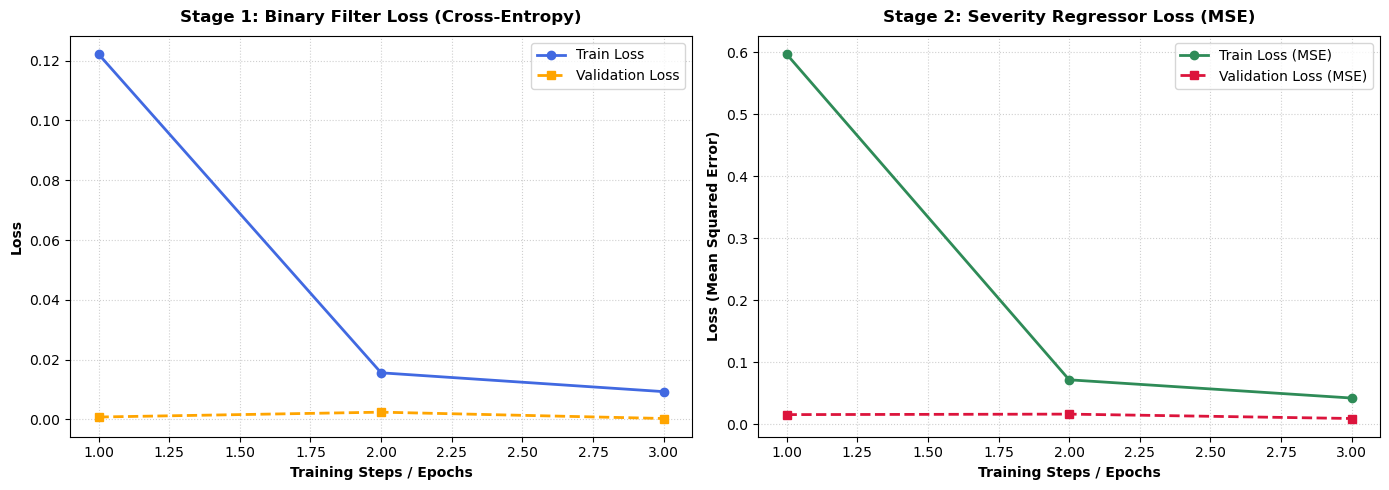

In [21]:
def extract_loss_history(trainer):
    """פונקציית עזר לחילוץ ה-Loss מתוך היסטוריית האימון של ה-Trainer"""
    train_loss, val_loss = [], []
    for log in trainer.state.log_history:
        if 'loss' in log: # זה ה-Train Loss
            train_loss.append(log['loss'])
        if 'eval_loss' in log: # זה ה-Validation Loss
            val_loss.append(log['eval_loss'])
    
    min_len = min(len(train_loss), len(val_loss))
    return train_loss[:min_len], val_loss[:min_len]

s1_train, s1_val = extract_loss_history(trainer_stage1)
s2_train, s2_val = extract_loss_history(trainer_stage2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# grafh 1 
epochs_s1 = range(1, len(s1_train) + 1)
ax1.plot(epochs_s1, s1_train, 'o-', color='royalblue', label='Train Loss', linewidth=2)
ax1.plot(epochs_s1, s1_val, 's--', color='orange', label='Validation Loss', linewidth=2)
ax1.set_title("Stage 1: Binary Filter Loss (Cross-Entropy)", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Training Steps / Epochs", fontsize=10, fontweight='bold')
ax1.set_ylabel("Loss", fontsize=10, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)

#grafh 2
epochs_s2 = range(1, len(s2_train) + 1)
ax2.plot(epochs_s2, s2_train, 'o-', color='seagreen', label='Train Loss (MSE)', linewidth=2)
ax2.plot(epochs_s2, s2_val, 's--', color='crimson', label='Validation Loss (MSE)', linewidth=2)
ax2.set_title("Stage 2: Severity Regressor Loss (MSE)", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel("Training Steps / Epochs", fontsize=10, fontweight='bold')
ax2.set_ylabel("Loss (Mean Squared Error)", fontsize=10, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()

# save pic 
plt.savefig("bert_cascade_learning_curves.png", dpi=300)
plt.show()